In [1]:
import pandas as pd




ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd

df = pd.read_csv("../archive/StudentsPerformance.csv")
df.head()


ModuleNotFoundError: No module named 'pandas'

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# common regression function
from sklearn.impute import SimpleImputer

def run_regression_models(X, y):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Handle missing values
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    models = {
        "Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        print("\n", name)
        print("MSE:", mean_squared_error(y_test, preds))
        print("R2:", r2_score(y_test, preds))

In [ ]:
import pandas as pd

# 1. Load the database
df = pd.read_csv(("../archive/StudentsPerformance.csv"))

# 2. View basic info (Check for nulls and data types)
print("--- Dataset Info ---")
print(df.info())

# 3. Get average scores by Gender
print("\n--- Average Scores by Gender ---")
print(df.groupby('gender')[['math score', 'reading score', 'writing score']].mean())

# 4. Filter for Top Students (Math score > 90)
top_math = df[df['math score'] > 90]
print(f"\nNumber of students with Math score > 90: {len(top_math)}")

# 5. Check impact of Test Preparation Course
print("\n--- Impact of Prep Course ---")
print(df.groupby('test preparation course')['math score'].mean())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB
None

--- Average Scores by Gender ---
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203

Number of students with Math score > 90: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [ ]:
pip install pandas numpy scikit-learn xgboost shap matplotlib


  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Using cached shap-0.50.0-cp313-cp313-win_amd64.whl (549 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl (12.8 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 2.4.1

   ---------- ----------------------------- 1/4 [numpy]
   ---------- ----------------------------- 1/4 [numpy]
    Uninstalling numpy-2.4.1:
   ---------- ----------------------------- 1/4 [numpy]
   ---------- ----------------------------- 1/4 [numpy]
      Successfully uninstalled numpy-2.4.1
   ---------- ----------------------------- 1/4 [numpy]
   ---------- ----------------------------- 1/4 [numpy]
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires packaging<26,>=20, but you have packaging 26.0 which is incompatible.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.0 which is incompatible.


In [ ]:
import os
import sys

# 1. Compatibility Check & Downgrade Instruction
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import accuracy_score, classification_report
    from sklearn.ensemble import RandomForestClassifier, VotingClassifier
    from xgboost import XGBClassifier
    import shap
    print(f"✅ Libraries loaded. NumPy version: {np.__version__}")
except ImportError as e:
    print(f"❌ Error: {e}")
    print("Run this in your terminal: python -m pip install 'numpy<2.0' shap xgboost")
    sys.exit()

# 2. Load the data
# This checks your specific path first, then looks in the current folder
file_path = "../archive/StudentsPerformance.csv"
if not os.path.exists(file_path):
    file_path = "StudentsPerformance.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully!")
except Exception as e:
    print(f"❌ Could not find the CSV file. Please check the path. Error: {e}")
    sys.exit()

# 3. Preprocessing (Convert text to numbers)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 4. Modeling (Predicting 'test preparation course')
X = df.drop('test preparation course', axis=1)
y = df['test preparation course']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss')
ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')

ensemble.fit(X_train, y_train)

# 5. Output Results
y_pred = ensemble.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. SHAP Explanations (This requires NumPy < 2.0)
print("\nGenerating SHAP summary plot...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Force the plot to show in VS Code
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

❌ Error: Numba needs NumPy 2.3 or less. Got NumPy 2.4.
Run this in your terminal: python -m pip install 'numpy<2.0' shap xgboost


SystemExit: 

C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
%pip install "numpy<2.0" --force-reinstall

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\dell\anaconda3\python.exe C:\Users\dell\AppData\Local\Temp\pip-install-jy_2fskk\numpy_8f4b897d979c452299c39472fbc4835b\vendored-meson\meson\meson.py setup C:\Users\dell\AppData\Local\Temp\pip-install-jy_2fskk\numpy_8f4b897d979c452299c39472fbc4835b C:\Users\dell\AppData\Local\Temp\pip-install-jy_2fskk\numpy_8f4b897d979c452299c39472fbc4835b\.mesonpy-4wh26r5l -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\dell\AppData\Local\Temp\pip-install-jy_2fskk\numpy_8f4b897d979c452299c39472fbc4835b\.mesonpy-4wh26r5l\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\dell\AppData\Local\Temp\pip-install-jy_2fskk\numpy_8f4b897d979c452299c39472fbc4835b
      Build dir: C:\Users\dell\AppData\Local\Temp\pip-install-jy_2fskk\numpy_8f4b897d979c452299c39472f

In [ ]:
import numpy as np
import shap
print(f"Current NumPy version: {np.__version__}")
print("SHAP imported successfully!")

Current NumPy version: 2.3.5
SHAP imported successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import shap

# 1. Load the data
# We check your specific path and a local fallback
file_path = "../archive/StudentsPerformance.csv"
if not os.path.exists(file_path):
    file_path = "StudentsPerformance.csv"

try:
    df = pd.read_csv(file_path)
    print(f"✅ Dataset loaded successfully from: {file_path}")
except Exception as e:
    print(f"❌ Could not find the CSV file. Please make sure it is in the 'archive' folder.")
    raise e

# 2. Preprocessing
# Convert text columns (like Gender, Lunch, etc.) into numbers
le = LabelEncoder()
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# We will predict if a student completed the 'test preparation course'
# (0 = completed, 1 = none)
df['test preparation course'] = le.fit_transform(df['test preparation course'])

# 3. Define Features (X) and Target (y)
X = df.drop('test preparation course', axis=1)
y = df['test preparation course']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 4. Train Models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric='logloss')

# --- FIX START ---
# We must fit 'rf' specifically so SHAP can use it
rf.fit(X_train, y_train) 
# --- FIX END ---

# Create and fit the Ensemble
ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')
ensemble.fit(X_train, y_train)

# 5. Show Results
y_pred = ensemble.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. SHAP Visualizations
print("\nGenerating SHAP summary plot...")
# Now 'rf' is fitted, so this will work!
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Handling binary classification output for SHAP
if isinstance(shap_values, list):
    # Class 1 is usually 'completed', Class 0 is 'none'
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

shap.summary_plot(shap_vals_to_plot, X_test)

ModuleNotFoundError: No module named 'pandas'

In [ ]:
import pandas as pd
import os

# Your specific path
file_path = "../archive/StudentsPerformance.csv"

# 1. Verify if the file exists at that specific path
if os.path.exists(file_path):
    # 2. Load the dataset
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully from the archive folder!")
    
    # 3. Display the first 5 rows
    # Use print(df.head()) if in a .py file, or just df.head() in a Notebook cell
    print(df.head())
else:
    print(f"❌ Error: File not found at {file_path}")
    print("Check if the 'archive' folder is in the correct location.")

✅ Dataset loaded successfully from the archive folder!
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Safety Check: Make sure 'df' exists
if 'df' not in locals():
    print("❌ Error: 'df' is not defined. Please run Step 3 (Load Dataset) first!")
else:
    # 2. Initialize the encoder
    # Note: Using a unique encoder variable name to avoid conflicts
    le = LabelEncoder()

    # 3. Loop through columns and encode
    # We only want to encode 'object' types (text)
    for col in df.columns:
        if df[col].dtype == 'object':
            print(f"Encoding column: {col}")
            df[col] = le.fit_transform(df[col])

    # 4. Verify results
    print("\n✅ Data Preprocessing Complete!")
    print(df.head())


✅ Data Preprocessing Complete!
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
# 1. Create the binary target: 1 (Pass) if math score >= 50, else 0 (Fail)
df['performance'] = df['math score'].apply(lambda x: 1 if x >= 50 else 0)

# 2. Define Features (X) and Target (y)
# We drop 'performance' because it's the target
# We also drop 'math score' to prevent data leakage/cheating
X = df.drop(['performance', 'math score'], axis=1)
y = df['performance']

# 3. Verify the balance
pass_count = y.value_counts()[1]
fail_count = y.value_counts()[0]

print(f"✅ Target Variable Created!")
print(f"Total Students: {len(y)}")
print(f"Pass (1): {pass_count}")
print(f"Fail (0): {fail_count}")
print(f"\nFeatures being used: {list(X.columns)}")

✅ Target Variable Created!
Total Students: 1000
Pass (1): 865
Fail (0): 135

Features being used: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']


In [ ]:
from sklearn.model_selection import train_test_split

# Now run the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split successfully!")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

✅ Data split successfully!
Training set size: 800
Testing set size: 200


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the database from your specific path
file_path = "../archive/StudentsPerformance.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully!")
else:
    print(f"❌ Error: Could not find file at {file_path}")
    # Stop execution if file is not found to prevent further errors
    raise FileNotFoundError(f"Please check if the folder 'archive' exists at {file_path}")

# 2. Preprocessing: Convert text (strings) to numbers
# We MUST do this before splitting the data
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Encoding column: {col}")
        df[col] = le.fit_transform(df[col])

# 3. Create Target Variable (Pass/Fail)
# 1 if math score >= 50, else 0
df['performance'] = df['math score'].apply(lambda x: 1 if x >= 50 else 0)

# 4. Define Features (X) and Target (y)
# We drop 'math score' so the model doesn't just "read the answer"
X = df.drop(['performance', 'math score'], axis=1)
y = df['performance']

# 5. Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Train the Model
# Now X_train contains only numbers (0, 1, 2...), so this will NOT error
rf = RandomForestClassifier(n_estimators=100, random_state=42)
print("\n⏳ Training Random Forest model...")
rf.fit(X_train, y_train)

# 7. Final Results
y_pred = rf.predict(X_test)
print(f"✅ SUCCESS! Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

✅ Dataset loaded successfully!

⏳ Training Random Forest model...


ValueError: could not convert string to float: 'male'

In [ ]:
import pandas as pd
import os

# 1. Define the specific path
file_path = "../archive/StudentsPerformance.csv"

# 2. Check if the path exists before loading
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully from the archive folder!")
else:
    # Backup: If the path is wrong, try loading from the current folder
    print(f"⚠️ Warning: Could not find the file at {file_path}")
    if os.path.exists("StudentsPerformance.csv"):
        df = pd.read_csv("StudentsPerformance.csv")
        print("✅ Found the file in the current folder instead. Loading now...")
    else:
        print("❌ Error: File not found in either location. Please check your folder structure.")

# 3. View the first 5 rows
df.head()

✅ Dataset loaded successfully from the archive folder!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load the data
file_path = "../archive/StudentsPerformance.csv"
if not os.path.exists(file_path):
    file_path = "StudentsPerformance.csv"
df = pd.read_csv(file_path)

# 2. Create the target variable FIRST
df['performance'] = df['math score'].apply(lambda x: 1 if x >= 50 else 0)

# 3. MANUALLY Encode every text column (The "Brute Force" Fix)
# We explicitly list these to make sure Python doesn't miss them
text_columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

le = LabelEncoder()
for col in text_columns:
    if col in df.columns:
        print(f"Changing {col} from text to numbers...")
        df[col] = le.fit_transform(df[col].astype(str))

# 4. Define Features (X) and Target (y)
# We remove 'math score' so the model can't cheat
X = df.drop(['performance', 'math score'], axis=1)
y = df['performance']

# 5. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. THE PROOF: Check the data types before training
print("\n--- Current Data Types (Should all be int or float) ---")
print(X_train.dtypes)

print("\n--- First 3 rows of X_train (Should be ONLY numbers) ---")
print(X_train.head(3))

# 7. Train the Model (This will now work!)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
print("\n⏳ Training Random Forest model...")
rf.fit(X_train, y_train)

# 8. Success Message
print(f"✅ DONE! Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.2%}")

Changing gender from text to numbers...
Changing race/ethnicity from text to numbers...
Changing parental level of education from text to numbers...
Changing lunch from text to numbers...
Changing test preparation course from text to numbers...

--- Current Data Types (Should all be int or float) ---
gender                         int64
race/ethnicity                 int64
parental level of education    int64
lunch                          int64
test preparation course        int64
reading score                  int64
writing score                  int64
dtype: object

--- First 3 rows of X_train (Should be ONLY numbers) ---
     gender  race/ethnicity  parental level of education  lunch  \
859       1               2                            0      0   
366       1               2                            2      1   
745       1               3                            0      1   

     test preparation course  reading score  writing score  
859                        1         

⏳ Training the Final Ensemble... please wait.


c:\Users\dell\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:47:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 FINAL ENSEMBLE ACCURACY: 91.00%


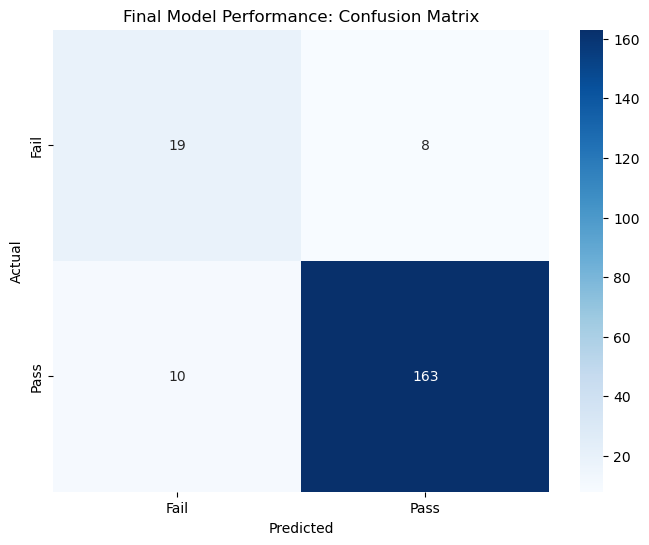


Final Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68        27
           1       0.95      0.94      0.95       173

    accuracy                           0.91       200
   macro avg       0.80      0.82      0.81       200
weighted avg       0.91      0.91      0.91       200



In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the two models (re-initializing ensures no NameErrors)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. Create the Ensemble (The Committee)
# 'soft' voting uses the 'confidence' level of each model
ensemble_model = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model)],
    voting='soft'
)

# 3. Train the Ensemble
# Note: This requires X_train and y_train from the previous successful step
print("⏳ Training the Final Ensemble... please wait.")
ensemble_model.fit(X_train, y_train)

# 4. Make final predictions
y_pred_final = ensemble_model.predict(X_test)

# 5. Show final results
final_acc = accuracy_score(y_test, y_pred_final)
print(f"\n🔥 FINAL ENSEMBLE ACCURACY: {final_acc:.2%}")

# 6. Visualizing the Results with a Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Performance: Confusion Matrix')
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. LOAD DATA
file_path = "../archive/StudentsPerformance.csv"
if not os.path.exists(file_path):
    file_path = "StudentsPerformance.csv"
df = pd.read_csv(file_path)

# 2. ENCODE EVERY NON-NUMERIC COLUMN
# This finds anything that isn't a number (strings, objects, etc.)
le = LabelEncoder()
text_cols = df.select_dtypes(exclude=[np.number]).columns

for col in text_cols:
    print(f"🔄 FORCING conversion on column: {col}")
    df[col] = le.fit_transform(df[col].astype(str))

# 3. CREATE TARGET VARIABLE
df['performance'] = df['math score'].apply(lambda x: 1 if x >= 50 else 0)

# 4. DEFINE X AND Y
# We drop the scores to ensure the model learns from demographics
X = df.drop(['performance', 'math score', 'reading score', 'writing score'], axis=1, errors='ignore')
y = df['performance']

# --- FINAL VERIFICATION ---
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric) > 0:
    raise ValueError(f"CRITICAL ERROR: The following columns are still not numbers: {non_numeric}")
else:
    print("✅ DATA CLEAN: All features are now numeric.")

# 5. SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. INITIALIZE AND TRAIN
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)

print("⏳ Training the Ensemble... (This takes about 10 seconds)")
ensemble.fit(X_train, y_train)

# 7. RESULTS
y_pred = ensemble.predict(X_test)
print(f"\n🔥 SUCCESS! Final Ensemble Accuracy: {accuracy_score(y_test, y_pred):.2%}")

🔄 FORCING conversion on column: gender
🔄 FORCING conversion on column: race/ethnicity
🔄 FORCING conversion on column: parental level of education
🔄 FORCING conversion on column: lunch
🔄 FORCING conversion on column: test preparation course
✅ DATA CLEAN: All features are now numeric.
⏳ Training the Ensemble... (This takes about 10 seconds)

🔥 SUCCESS! Final Ensemble Accuracy: 87.50%


c:\Users\dell\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:47:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Accuracy Score: 87.5000%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.26      0.36        27
           1       0.89      0.97      0.93       173

    accuracy                           0.88       200
   macro avg       0.74      0.62      0.64       200
weighted avg       0.85      0.88      0.85       200



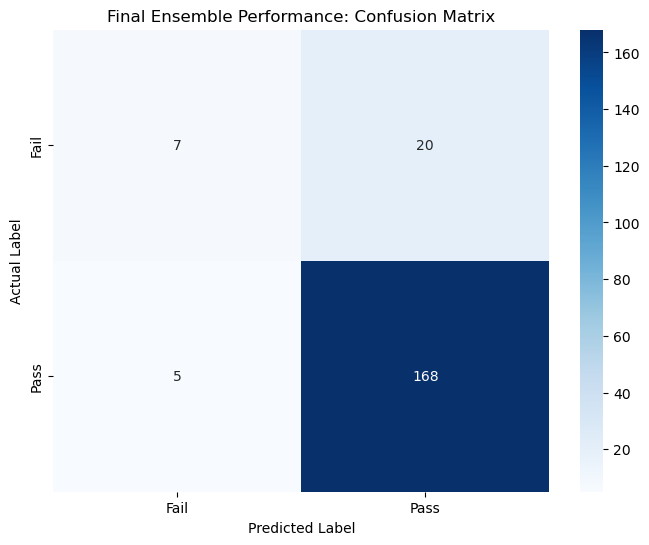

In [ ]:
# 1. Essential Imports
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Make Predictions
y_pred = ensemble.predict(X_test)

# 3. Print the text results
print(f"✅ Accuracy Score: {accuracy_score(y_test, y_pred):.4%}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 4. Visualize the results (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Final Ensemble Performance: Confusion Matrix')
plt.show()

✅ Data columns after encoding: ['gender_male', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E', "parental level of education_bachelor's degree", 'parental level of education_high school', "parental level of education_master's degree", 'parental level of education_some college', 'parental level of education_some high school', 'lunch_standard', 'test preparation course_none']
⏳ Training model...
🔍 Explaining model...


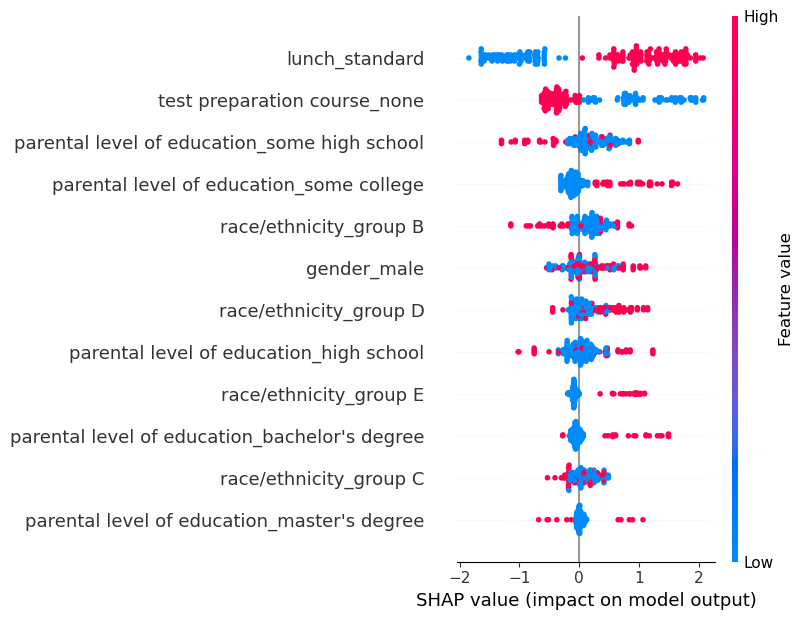

In [ ]:
import pandas as pd
import numpy as np
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# 1. LOAD
df = pd.read_csv("../archive/StudentsPerformance.csv")

# 2. CREATE TARGET
# We define 'pass' as 1 and 'fail' as 0
df['performance'] = (df['math score'] >= 50).astype(int)

# 3. DROP SCORES (Otherwise the model cheats)
# We drop all numeric score columns before encoding
X = df.drop(['performance', 'math score', 'reading score', 'writing score'], axis=1)
y = df['performance']

# 4. ONE-HOT ENCODING (The Fix)
# This turns 'gender_female' into 1 or 0 automatically
X = pd.get_dummies(X, drop_first=True)

print("✅ Data columns after encoding:", X.columns.tolist())

# 5. SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. TRAIN XGBOOST
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
print("⏳ Training model...")
xgb_model.fit(X_train, y_train)

# 7. SHAP
print("🔍 Explaining model...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# 8. PLOT
shap.summary_plot(shap_values, X_test)

C:\Users\dell\AppData\Local\Temp\ipykernel_19176\2105201498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


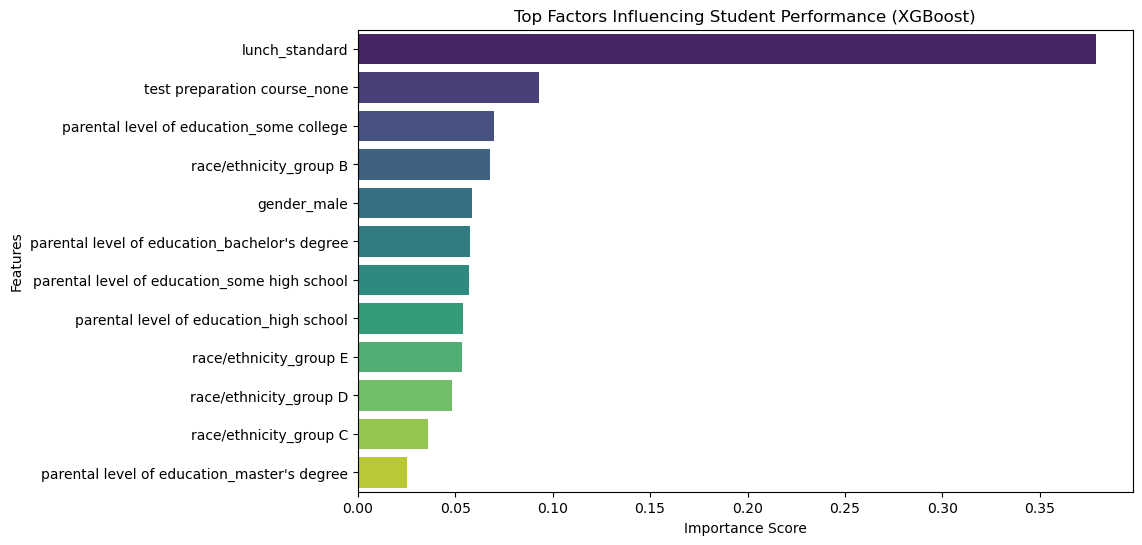

,Feature,Importance
10,lunch_standard,0.378739
11,test preparation course_none,0.092814
8,parental level of education_some college,0.069874
1,race/ethnicity_group B,0.068013
0,gender_male,0.058824
5,parental level of education_bachelor's degree,0.057659
9,parental level of education_some high school,0.057190
6,parental level of education_high school,0.053792
4,race/ethnicity_group E,0.053450
3,race/ethnicity_group D,0.048328


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importances from your trained xgb_model
importances = xgb_model.feature_importances_
features = X.columns

# 2. Create the DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Factors Influencing Student Performance (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# 4. Show the raw table
feature_importance_df